# 03 - Analyze Dependabot Results

This notebook turns the classified outputs from `02_classify_dependabot_usage.ipynb` into systematic filtering tables, adoption-time results, figures, and interpretation.

No GitHub API calls are made here.

## Interpretation Roadmap

The analysis has two levels:

1. **Repo-level history**: among the 742 unique downstream repositories, did the project ever use Dependabot in the mined history?
2. **Adoption-time status**: for each CVE-UP-DOWN adoption event, was Dependabot already enabled by the downstream adoption commit date?

These are intentionally different. A repository may adopt one vulnerable dependency before enabling Dependabot, then adopt another later after Dependabot was enabled. Those repositories are classified as mixed in the adoption-time repo aggregation.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parents[1]
DATA_DIR = ROOT / 'data' / 'rq3'
TABLE_DIR = ROOT / 'tables'
FIGURE_DIR = ROOT / 'figures'

PAIRWISE_CSV = DATA_DIR / 'dependabot_pairwise_classified.csv'
REPO_CSV = DATA_DIR / 'dependabot_repo_classified.csv'

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

## Load Classified Data

In [2]:
pairwise = pd.read_csv(PAIRWISE_CSV)
repos = pd.read_csv(REPO_CSV)

pairwise['adoption_date_utc'] = pd.to_datetime(pairwise['adoption_date_utc'], errors='coerce', utc=True)
pairwise['delay_release_days'] = pd.to_numeric(pairwise['delay_release'], errors='coerce')
pairwise['uses_dependabot_at_adoption'] = pairwise['dependabot_status_at_adoption'].ne('no_dependabot_evidence_at_adoption')
pairwise['any_dependabot_at_adoption'] = np.where(
    pairwise['uses_dependabot_at_adoption'],
    'any_dependabot_at_adoption',
    'no_dependabot_at_adoption',
)
if 'dependabot_setting_at_adoption' not in pairwise.columns:
    pairwise['dependabot_setting_at_adoption'] = pairwise['dependabot_status_at_adoption'].map({
        'no_dependabot_evidence_at_adoption': 'No Dependabot evidence',
        'security_only_at_adoption': 'Security updates only',
        'version_updates_enabled_at_adoption': 'Version updates enabled',
    }).fillna('Unclassified')
if 'adoption_time_setting_precise' not in pairwise.columns:
    pairwise['adoption_time_setting_precise'] = pairwise['dependabot_status_at_adoption'].map({
        'no_dependabot_evidence_at_adoption': 'No Dependabot evidence',
        'security_only_at_adoption': 'Security updates only',
        'version_updates_enabled_at_adoption': 'Version updates enabled',
    }).fillna('Unclassified')
if 'include_in_precise_setting_delay_analysis' not in pairwise.columns:
    pairwise['include_in_precise_setting_delay_analysis'] = pairwise['dependabot_status_at_adoption'].isin([
        'no_dependabot_evidence_at_adoption',
        'security_only_at_adoption',
        'version_updates_enabled_at_adoption',
    ])
if 'repo_strategy_security_then_version' not in pairwise.columns:
    pairwise['repo_strategy_security_then_version'] = pairwise['dependabot_lifecycle'].eq('security_then_version')

for col in ['uses_dependabot_ever', 'has_dependabot_pr', 'has_dependabot_config', 'security_first_version_later_ever']:
    if col in repos.columns:
        repos[col] = repos[col].astype(str).str.lower().map({'true': True, 'false': False}).fillna(False)

print(f'Pairwise adoption events: {len(pairwise):,}')
print(f'Unique downstream repos in pairwise data: {pairwise["normalized_downstream_repo"].nunique():,}')
print(f'Repo-level classified rows: {len(repos):,}')
display(pairwise.head(3))
display(repos.head(3))

Pairwise adoption events: 1,677
Unique downstream repos in pairwise data: 742
Repo-level classified rows: 742


,CVE,upstream_GA,downstream_GA,downstream_repo,commit_url,adoption_date,commit_n_CVEs,class,pattern,original_pattern,...,any_dependabot_at_adoption,dependabot_setting_at_adoption,adoption_time_setting_precise,include_in_precise_setting_delay_analysis,security_then_version_later_ever,repo_strategy_security_then_version,security_only_at_adoption_then_version_later,days_pr_before_adoption,days_config_before_adoption,delay_release_days
0,CVE-2021-37714,org.jsoup:jsoup,com.github.btheu.estivate:estivate,btheu/estivate,https://github.com/btheu/estivate/commit/22adf...,2021-12-03 15:44:15,1,Transparent,T1,T1,...,any_dependabot_at_adoption,Security updates only,Security updates only,True,False,False,False,416.898935,NaN,110.003472
1,CVE-2021-37714,org.jsoup:jsoup,com.jcabi:jcabi-http,jcabi/jcabi-http,https://github.com/jcabi/jcabi-http/commit/1a2...,2021-08-16 23:00:43,1,Transparent,T1,T1,...,any_dependabot_at_adoption,Version updates enabled,Version updates enabled,True,True,True,False,642.712222,49.888264,1.306574
2,CVE-2021-37714,org.jsoup:jsoup,in.ashwanthkumar:gocd-java-client,ashwanthkumar/gocd-java-client,https://github.com/ashwanthkumar/gocd-java-cli...,2021-09-30 23:03:50,1,Transparent,T1,T1,...,any_dependabot_at_adoption,Version updates enabled,Version updates enabled,True,True,True,False,523.619201,154.309317,46.308738


,repo,repo_url,uses_dependabot_ever,dependabot_usage_type_ever,dependabot_lifecycle,security_first_version_later_ever,has_dependabot_pr,first_dependabot_pr_date,first_dependabot_pr_url,first_dependabot_pr_number,first_dependabot_pr_author,first_dependabot_pr_title,has_dependabot_config,dependabot_config_path,dependabot_config_created_date,dependabot_config_created_sha,dependabot_config_created_url,days_security_to_version,mined_at_utc
0,42BV/jarb,https://github.com/42BV/jarb,True,security_updates_only,security_only_ever,False,True,2020-01-21T21:11:51Z,https://github.com/42BV/jarb/pull/53,53.0,dependabot,Bump spring.version from 5.1.3.RELEASE to 5.2....,False,NaN,NaN,NaN,NaN,NaN,2026-08-14T17:00:36.520962+00:00
1,52North/arctic-sea,https://github.com/52North/arctic-sea,True,both_security_and_version_updates,security_then_version,True,True,2019-08-01T21:59:32Z,https://github.com/52North/arctic-sea/pull/47,47.0,dependabot,Bump version.jackson from 2.9.9 to 2.10.0.pr1,True,.github/dependabot.yml,2021-04-29T15:25:46Z,fe7416a0a9a56c960616fe58de41f1e5b0e19049,https://github.com/52North/arctic-sea/commit/f...,636.726551,2026-08-14T17:00:42.593324+00:00
2,52North/series-hibernate,https://github.com/52North/series-hibernate,True,version_updates_config_only,version_config_only_ever,False,False,NaN,NaN,NaN,NaN,NaN,True,.github/dependabot.yml,2021-04-29T15:25:57Z,924fab33f054d8521a2e2ade95609ec9f0aba51b,https://github.com/52North/sensorweb-server-db...,NaN,2026-08-14T17:00:50.205286+00:00


## Table 1: Systematic Filtering

This table keeps the units explicit. The first row is adoption events. The second row is the unique downstream repository set mined for Dependabot evidence. The remaining rows summarize either full repo history or adoption-time evidence.

In [3]:
total_pairs = len(pairwise)
unique_repos = pairwise['normalized_downstream_repo'].nunique()
repos_using_ever = int(repos['uses_dependabot_ever'].sum())
repos_not_using_ever = unique_repos - repos_using_ever
pairs_using_at_adoption = int(pairwise['uses_dependabot_at_adoption'].sum())
pairs_not_using_at_adoption = total_pairs - pairs_using_at_adoption

repo_event = pairwise.groupby('normalized_downstream_repo')['uses_dependabot_at_adoption'].agg(['any', 'all']).reset_index()
repos_any_at_adoption = int(repo_event['any'].sum())
repos_none_at_adoption = unique_repos - repos_any_at_adoption
repos_all_at_adoption = int(repo_event['all'].sum())
repos_mixed_at_adoption = int((repo_event['any'] & ~repo_event['all']).sum())

filtering_table = pd.DataFrame([
    {'stage': 'RQ2 CVE-UP-DOWN adoption pairs loaded', 'unit': 'adoption pairs', 'count': total_pairs, 'percent_of_unit_base': 100.0, 'base': total_pairs},
    {'stage': 'Unique downstream repositories identified', 'unit': 'repositories', 'count': unique_repos, 'percent_of_unit_base': 100.0, 'base': unique_repos},
    {'stage': 'Repositories with Dependabot evidence ever', 'unit': 'repositories', 'count': repos_using_ever, 'percent_of_unit_base': repos_using_ever / unique_repos * 100, 'base': unique_repos},
    {'stage': 'Repositories with no Dependabot evidence ever', 'unit': 'repositories', 'count': repos_not_using_ever, 'percent_of_unit_base': repos_not_using_ever / unique_repos * 100, 'base': unique_repos},
    {'stage': 'Adoption pairs with Dependabot evidence by adoption date', 'unit': 'adoption pairs', 'count': pairs_using_at_adoption, 'percent_of_unit_base': pairs_using_at_adoption / total_pairs * 100, 'base': total_pairs},
    {'stage': 'Adoption pairs with no Dependabot evidence by adoption date', 'unit': 'adoption pairs', 'count': pairs_not_using_at_adoption, 'percent_of_unit_base': pairs_not_using_at_adoption / total_pairs * 100, 'base': total_pairs},
    {'stage': 'Repositories using Dependabot in at least one observed adoption event', 'unit': 'repositories', 'count': repos_any_at_adoption, 'percent_of_unit_base': repos_any_at_adoption / unique_repos * 100, 'base': unique_repos},
    {'stage': 'Repositories with no Dependabot evidence in any observed adoption event', 'unit': 'repositories', 'count': repos_none_at_adoption, 'percent_of_unit_base': repos_none_at_adoption / unique_repos * 100, 'base': unique_repos},
    {'stage': 'Repositories with mixed adoption-time status', 'unit': 'repositories', 'count': repos_mixed_at_adoption, 'percent_of_unit_base': repos_mixed_at_adoption / unique_repos * 100, 'base': unique_repos},
])

filtering_table.to_csv(TABLE_DIR / 'rq3_systematic_filtering.csv', index=False)
display(filtering_table)

,stage,unit,count,percent_of_unit_base,base
0,RQ2 CVE-UP-DOWN adoption pairs loaded,adoption pairs,1677,100.000000,1677
1,Unique downstream repositories identified,repositories,742,100.000000,742
2,Repositories with Dependabot evidence ever,repositories,580,78.167116,742
3,Repositories with no Dependabot evidence ever,repositories,162,21.832884,742
4,Adoption pairs with Dependabot evidence by ado...,adoption pairs,684,40.787120,1677
5,Adoption pairs with no Dependabot evidence by ...,adoption pairs,993,59.212880,1677
6,Repositories using Dependabot in at least one ...,repositories,313,42.183288,742
7,Repositories with no Dependabot evidence in an...,repositories,429,57.816712,742
8,Repositories with mixed adoption-time status,repositories,89,11.994609,742


**Interpretation.** The repo-history view and adoption-time view answer different questions. In full repository history, 580 of 742 downstream projects show Dependabot evidence. But at the adoption-event level, only adoption events where evidence existed on or before the adoption commit date count as Dependabot-assisted adoption-time cases. This is why the adoption-time count is lower than the ever-used count.

## Table 2: Repo-Level Dependabot History

This table ignores adoption dates and asks whether each downstream project ever used Dependabot in the mined history.

In [4]:
usage_order = [
    'not_using_dependabot',
    'security_updates_only',
    'version_updates_config_only',
    'both_security_and_version_updates',
]
usage_labels = {
    'not_using_dependabot': 'No Dependabot evidence ever',
    'security_updates_only': 'Security updates only',
    'version_updates_config_only': 'Version config only',
    'both_security_and_version_updates': 'Both security and version updates',
}

repo_history_usage = repos.groupby('dependabot_usage_type_ever', dropna=False).agg(
    repositories=('repo', 'nunique')
).reindex(usage_order).reset_index()
repo_history_usage['label'] = repo_history_usage['dependabot_usage_type_ever'].map(usage_labels)
repo_history_usage['percent_of_repositories'] = repo_history_usage['repositories'] / unique_repos * 100
repo_history_usage = repo_history_usage[['dependabot_usage_type_ever', 'label', 'repositories', 'percent_of_repositories']]
repo_history_usage.to_csv(TABLE_DIR / 'rq3_repo_history_usage_type.csv', index=False)

lifecycle_order = [
    'never_detected',
    'security_only_ever',
    'version_config_only_ever',
    'security_then_version',
    'same_day_security_and_version',
    'version_then_security',
]
lifecycle_labels = {
    'never_detected': 'Never detected',
    'security_only_ever': 'Security only ever',
    'version_config_only_ever': 'Version config only ever',
    'security_then_version': 'Security first, version later',
    'same_day_security_and_version': 'Security and version same day',
    'version_then_security': 'Version first, security later',
}
repo_history_lifecycle = repos.groupby('dependabot_lifecycle', dropna=False).agg(
    repositories=('repo', 'nunique')
).reindex(lifecycle_order).reset_index()
repo_history_lifecycle['label'] = repo_history_lifecycle['dependabot_lifecycle'].map(lifecycle_labels)
repo_history_lifecycle['percent_of_repositories'] = repo_history_lifecycle['repositories'] / unique_repos * 100
repo_history_lifecycle = repo_history_lifecycle[['dependabot_lifecycle', 'label', 'repositories', 'percent_of_repositories']]
repo_history_lifecycle.to_csv(TABLE_DIR / 'rq3_repo_history_lifecycle.csv', index=False)

display(repo_history_usage)
display(repo_history_lifecycle)

,dependabot_usage_type_ever,label,repositories,percent_of_repositories
0,not_using_dependabot,No Dependabot evidence ever,162,21.832884
1,security_updates_only,Security updates only,371,50.000000
2,version_updates_config_only,Version config only,35,4.716981
3,both_security_and_version_updates,Both security and version updates,174,23.450135


,dependabot_lifecycle,label,repositories,percent_of_repositories
0,never_detected,Never detected,162,21.832884
1,security_only_ever,Security only ever,371,50.000000
2,version_config_only_ever,Version config only ever,35,4.716981
3,security_then_version,"Security first, version later",147,19.811321
4,same_day_security_and_version,Security and version same day,21,2.830189
5,version_then_security,"Version first, security later",6,0.808625


**Interpretation.** This is the broad adoption baseline. It says how common Dependabot became among downstream projects at any point in their repository histories. It does not imply Dependabot was already enabled when every CVE adoption occurred.

## Table 3: Adoption-Time Pair-Level Status

This table uses each adoption commit date as the cutoff. A Dependabot PR or config file counts only if it appeared on or before that adoption date.

In [5]:
status_order = [
    'no_dependabot_evidence_at_adoption',
    'security_only_at_adoption',
    'version_updates_enabled_at_adoption',
]
status_labels = {
    'no_dependabot_evidence_at_adoption': 'No Dependabot evidence at adoption',
    'security_only_at_adoption': 'Security only at adoption',
    'version_updates_enabled_at_adoption': 'Version updates enabled at adoption',
}

pair_status = pairwise.groupby('dependabot_status_at_adoption', dropna=False).agg(
    adoption_pairs=('dependabot_status_at_adoption', 'size'),
    downstream_repositories=('normalized_downstream_repo', 'nunique'),
    cves=('CVE', 'nunique'),
).reindex(status_order).reset_index()
pair_status['label'] = pair_status['dependabot_status_at_adoption'].map(status_labels)
pair_status['percent_of_adoption_pairs'] = pair_status['adoption_pairs'] / total_pairs * 100
pair_status = pair_status[['dependabot_status_at_adoption', 'label', 'adoption_pairs', 'downstream_repositories', 'cves', 'percent_of_adoption_pairs']]
pair_status.to_csv(TABLE_DIR / 'rq3_adoption_time_pair_status.csv', index=False)
display(pair_status)

,dependabot_status_at_adoption,label,adoption_pairs,downstream_repositories,cves,percent_of_adoption_pairs
0,no_dependabot_evidence_at_adoption,No Dependabot evidence at adoption,993,518,168,59.212880
1,security_only_at_adoption,Security only at adoption,542,251,133,32.319618
2,version_updates_enabled_at_adoption,Version updates enabled at adoption,142,74,44,8.467501


**Interpretation.** This is the central adoption-time result. Most adoption events occurred before any Dependabot evidence was observed for that downstream repository. Among adoption events with Dependabot evidence, the dominant signal is Dependabot PR evidence without a config file, which we interpret as security updates only.

## Table 4: Repo-Level Adoption-Time Aggregation

Because the same downstream repository may appear in multiple adoption pairs, repo-level adoption-time counts need an explicit rule.

In [6]:
pairwise_sorted = pairwise.sort_values(['normalized_downstream_repo', 'adoption_date_utc', 'CVE', 'upstream_GA', 'downstream_GA'])
earliest = pairwise_sorted.drop_duplicates('normalized_downstream_repo', keep='first')
latest = pairwise_sorted.drop_duplicates('normalized_downstream_repo', keep='last')

def repo_rule_row(rule, subset, meaning):
    uses = int(subset['uses_dependabot_at_adoption'].sum())
    no = int((~subset['uses_dependabot_at_adoption']).sum())
    return {
        'repo_level_rule': rule,
        'uses_dependabot_at_adoption': uses,
        'no_dependabot_at_adoption': no,
        'total_repositories': len(subset),
        'percent_using_dependabot': uses / len(subset) * 100,
        'meaning': meaning,
    }

any_subset = repo_event.rename(columns={'any': 'uses_dependabot_at_adoption'})
repo_adoption_rules = pd.DataFrame([
    repo_rule_row('earliest_adoption_per_repo', earliest, 'Status at the first observed adoption event for each repo'),
    repo_rule_row('latest_adoption_per_repo', latest, 'Status at the latest observed adoption event for each repo'),
    repo_rule_row('any_adoption_event_per_repo', any_subset, 'Repo used Dependabot in at least one observed adoption event'),
])
repo_adoption_rules.to_csv(TABLE_DIR / 'rq3_repo_level_adoption_time_rules.csv', index=False)
display(repo_adoption_rules)

repo_event['transition_group'] = np.select(
    [
        ~repo_event['any'],
        repo_event['all'],
        repo_event['any'] & ~repo_event['all'],
    ],
    [
        'always_no_dependabot_at_observed_adoptions',
        'always_dependabot_at_observed_adoptions',
        'mixed_no_then_dependabot_across_observed_adoptions',
    ],
    default='unclassified',
)
transition_labels = {
    'always_no_dependabot_at_observed_adoptions': 'Always no Dependabot at adoption',
    'always_dependabot_at_observed_adoptions': 'Always Dependabot at adoption',
    'mixed_no_then_dependabot_across_observed_adoptions': 'Mixed across adoption events',
}
repo_transition = repo_event.groupby('transition_group').agg(
    repositories=('normalized_downstream_repo', 'nunique')
).reset_index()
repo_transition['label'] = repo_transition['transition_group'].map(transition_labels)
repo_transition['percent_of_repositories'] = repo_transition['repositories'] / unique_repos * 100
repo_transition = repo_transition[['transition_group', 'label', 'repositories', 'percent_of_repositories']]
repo_transition.to_csv(TABLE_DIR / 'rq3_repo_adoption_time_transition.csv', index=False)
display(repo_transition)

security_then_version_repos = repos[repos['dependabot_lifecycle'].eq('security_then_version')].copy()
security_only_then_version_pairs = pairwise[pairwise['security_only_at_adoption_then_version_later'].astype(str).str.lower().eq('true')].copy()
transition_days = pd.to_numeric(security_then_version_repos['days_security_to_version'], errors='coerce').dropna()
transition_median_days = transition_days.median()
transition_q1_days = transition_days.quantile(0.25)
transition_q3_days = transition_days.quantile(0.75)
security_then_version_strategy = pd.DataFrame([
    {
        'measure': 'Repositories with security-first then version-update lifecycle',
        'count': security_then_version_repos['repo'].nunique(),
        'base': unique_repos,
        'percent': security_then_version_repos['repo'].nunique() / unique_repos * 100,
        'median_transition_days': transition_median_days,
        'iqr_transition_days': f'{transition_q1_days:.1f}-{transition_q3_days:.1f}',
        'interpretation': 'First Dependabot PR evidence precedes dependabot.yml/yaml creation; repo appears to move from security-update evidence to version-update configuration.',
    },
    {
        'measure': 'Adoption pairs security-only at adoption but version config added later',
        'count': len(security_only_then_version_pairs),
        'base': total_pairs,
        'percent': len(security_only_then_version_pairs) / total_pairs * 100,
        'median_transition_days': np.nan,
        'iqr_transition_days': np.nan,
        'interpretation': 'At the adoption commit, only security-update evidence existed; version-update configuration appeared after that adoption event.',
    },
])
security_then_version_strategy.to_csv(TABLE_DIR / 'rq3_paper_T3_security_then_version_strategy.csv', index=False)
display(security_then_version_strategy)

,repo_level_rule,uses_dependabot_at_adoption,no_dependabot_at_adoption,total_repositories,percent_using_dependabot,meaning
0,earliest_adoption_per_repo,224,518,742,30.188679,Status at the first observed adoption event fo...
1,latest_adoption_per_repo,313,429,742,42.183288,Status at the latest observed adoption event f...
2,any_adoption_event_per_repo,313,429,742,42.183288,Repo used Dependabot in at least one observed ...


,transition_group,label,repositories,percent_of_repositories
0,always_dependabot_at_observed_adoptions,Always Dependabot at adoption,224,30.188679
1,always_no_dependabot_at_observed_adoptions,Always no Dependabot at adoption,429,57.816712
2,mixed_no_then_dependabot_across_observed_adopt...,Mixed across adoption events,89,11.994609


,measure,count,base,percent,median_transition_days,iqr_transition_days,interpretation
0,Repositories with security-first then version-...,147,742,19.811321,585.000301,351.9-936.8,First Dependabot PR evidence precedes dependab...
1,Adoption pairs security-only at adoption but v...,137,1677,8.169350,NaN,NaN,"At the adoption commit, only security-update e..."


**Interpretation.** The mixed group is expected and important. These projects were not using Dependabot for at least one observed adoption event, but did use Dependabot for a later observed adoption event. Therefore, repo-level ever-use counts should not be used as a substitute for adoption-time status.

## Table 5: Upstream Security Release-to-Adoption Delay

This section uses `delay_release` as the main outcome. It measures the number of days between the upstream security release and the downstream adoption commit. Positive values mean the downstream project adopted after the upstream security release.

In [7]:
delay_data = pairwise[pairwise['delay_release_days'].notna()].copy()

def summarize_delay(group_col, order=None, label_map=None):
    rows = []
    grouped = delay_data.groupby(group_col, dropna=False)
    keys = order if order is not None else list(grouped.groups.keys())
    for key in keys:
        if key not in grouped.groups:
            values = pd.Series(dtype=float)
            subset = delay_data.iloc[0:0]
        else:
            subset = grouped.get_group(key)
            values = subset['delay_release_days'].dropna()
        n = int(values.shape[0])
        rows.append({
            group_col: key,
            'label': label_map.get(key, key) if label_map else key,
            'adoption_pairs': n,
            'downstream_repositories': int(subset['normalized_downstream_repo'].nunique()) if n else 0,
            'cves': int(subset['CVE'].nunique()) if n else 0,
            'mean_delay_release_days': values.mean() if n else np.nan,
            'median_delay_release_days': values.median() if n else np.nan,
            'q1_delay_release_days': values.quantile(0.25) if n else np.nan,
            'q3_delay_release_days': values.quantile(0.75) if n else np.nan,
            'percent_after_release_gt_0d': (values.gt(0).mean() * 100) if n else np.nan,
            'percent_late_gt_7d': (values.gt(7).mean() * 100) if n else np.nan,
            'percent_late_gt_30d': (values.gt(30).mean() * 100) if n else np.nan,
            'percent_late_gt_90d': (values.gt(90).mean() * 100) if n else np.nan,
        })
    return pd.DataFrame(rows)

delay_by_status = summarize_delay(
    'dependabot_status_at_adoption',
    order=status_order,
    label_map=status_labels,
)
delay_by_status.to_csv(TABLE_DIR / 'rq3_delay_by_dependabot_status_at_adoption.csv', index=False)
display(delay_by_status)

any_order = ['no_dependabot_at_adoption', 'any_dependabot_at_adoption']
any_labels = {
    'no_dependabot_at_adoption': 'No Dependabot at adoption',
    'any_dependabot_at_adoption': 'Any Dependabot at adoption',
}
delay_any = summarize_delay(
    'any_dependabot_at_adoption',
    order=any_order,
    label_map=any_labels,
)
delay_any.to_csv(TABLE_DIR / 'rq3_delay_any_dependabot_vs_none.csv', index=False)
display(delay_any)

precise_setting_order = ['No Dependabot evidence', 'Security updates only', 'Version updates enabled']
full_delay_data = delay_data
delay_data = full_delay_data[full_delay_data['include_in_precise_setting_delay_analysis']].copy()
delay_by_precise_setting = summarize_delay(
    'adoption_time_setting_precise',
    order=precise_setting_order,
)
delay_by_precise_setting.to_csv(TABLE_DIR / 'rq3_delay_by_precise_setting_at_adoption.csv', index=False)
display(delay_by_precise_setting)
delay_data = full_delay_data

,dependabot_status_at_adoption,label,adoption_pairs,downstream_repositories,cves,mean_delay_release_days,median_delay_release_days,q1_delay_release_days,q3_delay_release_days,percent_after_release_gt_0d,percent_late_gt_7d,percent_late_gt_30d,percent_late_gt_90d
0,no_dependabot_evidence_at_adoption,No Dependabot evidence at adoption,993,518,168,287.984095,110.641308,22.478958,378.878067,94.763343,86.807654,71.601208,52.870091
1,security_only_at_adoption,Security only at adoption,542,251,133,318.049668,73.165075,9.974861,318.611916,98.708487,82.472325,63.837638,46.863469
2,version_updates_enabled_at_adoption,Version updates enabled at adoption,142,74,44,97.293882,10.365098,1.277789,100.954132,97.887324,56.338028,42.253521,30.985915


,any_dependabot_at_adoption,label,adoption_pairs,downstream_repositories,cves,mean_delay_release_days,median_delay_release_days,q1_delay_release_days,q3_delay_release_days,percent_after_release_gt_0d,percent_late_gt_7d,percent_late_gt_30d,percent_late_gt_90d
0,no_dependabot_at_adoption,No Dependabot at adoption,993,518,168,287.984095,110.641308,22.478958,378.878067,94.763343,86.807654,71.601208,52.870091
1,any_dependabot_at_adoption,Any Dependabot at adoption,684,313,135,272.220251,66.763084,8.671007,249.027587,98.538012,77.046784,59.356725,43.567251


,adoption_time_setting_precise,label,adoption_pairs,downstream_repositories,cves,mean_delay_release_days,median_delay_release_days,q1_delay_release_days,q3_delay_release_days,percent_after_release_gt_0d,percent_late_gt_7d,percent_late_gt_30d,percent_late_gt_90d
0,No Dependabot evidence,No Dependabot evidence,993,518,168,287.984095,110.641308,22.478958,378.878067,94.763343,86.807654,71.601208,52.870091
1,Security updates only,Security updates only,542,251,133,318.049668,73.165075,9.974861,318.611916,98.708487,82.472325,63.837638,46.863469
2,Version updates enabled,Version updates enabled,142,74,44,97.293882,10.365098,1.277789,100.954132,97.887324,56.338028,42.253521,30.985915


**Interpretation.** These tables directly test whether Dependabot presence at adoption time is associated with faster downstream mitigation after upstream security releases. The threshold columns show whether projects are still late despite having Dependabot evidence.

## Table 6: Lateness Thresholds by Dependabot Setting

The threshold table focuses on operational lateness: after release, more than 7 days, more than 30 days, and more than 90 days.

In [8]:
threshold_cols = [
    'percent_after_release_gt_0d',
    'percent_late_gt_7d',
    'percent_late_gt_30d',
    'percent_late_gt_90d',
]
lateness_thresholds = delay_by_status[[
    'dependabot_status_at_adoption', 'label', 'adoption_pairs', *threshold_cols
]].copy()
lateness_thresholds.to_csv(TABLE_DIR / 'rq3_lateness_thresholds_by_dependabot_status.csv', index=False)
display(lateness_thresholds)

# Keep the precise setting table as the main setting-level delay table.
# Version-update enablement is defined by the presence of dependabot.yml/yaml.
# Dependabot PR evidence may also exist in this group because version updates open PRs.
display(delay_by_precise_setting)

,dependabot_status_at_adoption,label,adoption_pairs,percent_after_release_gt_0d,percent_late_gt_7d,percent_late_gt_30d,percent_late_gt_90d
0,no_dependabot_evidence_at_adoption,No Dependabot evidence at adoption,993,94.763343,86.807654,71.601208,52.870091
1,security_only_at_adoption,Security only at adoption,542,98.708487,82.472325,63.837638,46.863469
2,version_updates_enabled_at_adoption,Version updates enabled at adoption,142,97.887324,56.338028,42.253521,30.985915


,adoption_time_setting_precise,label,adoption_pairs,downstream_repositories,cves,mean_delay_release_days,median_delay_release_days,q1_delay_release_days,q3_delay_release_days,percent_after_release_gt_0d,percent_late_gt_7d,percent_late_gt_30d,percent_late_gt_90d
0,No Dependabot evidence,No Dependabot evidence,993,518,168,287.984095,110.641308,22.478958,378.878067,94.763343,86.807654,71.601208,52.870091
1,Security updates only,Security updates only,542,251,133,318.049668,73.165075,9.974861,318.611916,98.708487,82.472325,63.837638,46.863469
2,Version updates enabled,Version updates enabled,142,74,44,97.293882,10.365098,1.277789,100.954132,97.887324,56.338028,42.253521,30.985915


**Interpretation.** This table helps separate tool presence from tool effectiveness. If a high percentage of Dependabot-at-adoption cases still exceed 30 or 90 days, then Dependabot availability alone is not sufficient for timely mitigation.

## Statistical Comparisons

These tests are descriptive support for the delay comparisons. They should be interpreted alongside effect sizes such as median delay differences and lateness percentages.

In [9]:
test_rows = []
try:
    from scipy import stats

    no_dep = delay_data.loc[delay_data['any_dependabot_at_adoption'].eq('no_dependabot_at_adoption'), 'delay_release_days'].dropna()
    any_dep = delay_data.loc[delay_data['any_dependabot_at_adoption'].eq('any_dependabot_at_adoption'), 'delay_release_days'].dropna()
    if len(no_dep) and len(any_dep):
        u_stat, p_value = stats.mannwhitneyu(no_dep, any_dep, alternative='two-sided')
        test_rows.append({
            'test': 'Mann-Whitney U',
            'comparison': 'No Dependabot at adoption vs any Dependabot at adoption',
            'groups': '2',
            'statistic': u_stat,
            'p_value': p_value,
            'n_1': len(no_dep),
            'n_2': len(any_dep),
            'median_1': no_dep.median(),
            'median_2': any_dep.median(),
            'median_difference_group2_minus_group1': any_dep.median() - no_dep.median(),
        })

    security_only = delay_data.loc[
        delay_data['dependabot_status_at_adoption'].eq('security_only_at_adoption'),
        'delay_release_days'
    ].dropna()
    version_enabled = delay_data.loc[
        delay_data['dependabot_status_at_adoption'].eq('version_updates_enabled_at_adoption'),
        'delay_release_days'
    ].dropna()
    if len(security_only) and len(version_enabled):
        u_stat, p_value = stats.mannwhitneyu(security_only, version_enabled, alternative='greater')
        test_rows.append({
            'test': 'Mann-Whitney U',
            'comparison': 'Security updates only vs version updates enabled; alternative: security-update delay is greater',
            'groups': '2',
            'statistic': u_stat,
            'p_value': p_value,
            'n_1': len(security_only),
            'n_2': len(version_enabled),
            'median_1': security_only.median(),
            'median_2': version_enabled.median(),
            'median_difference_group2_minus_group1': version_enabled.median() - security_only.median(),
        })

    kw_groups = [
        delay_data.loc[delay_data['dependabot_status_at_adoption'].eq(status), 'delay_release_days'].dropna()
        for status in status_order
    ]
    kw_groups = [group for group in kw_groups if len(group) > 0]
    if len(kw_groups) >= 2:
        h_stat, p_value = stats.kruskal(*kw_groups)
        test_rows.append({
            'test': 'Kruskal-Wallis',
            'comparison': 'Delay across Dependabot settings at adoption',
            'groups': str(len(kw_groups)),
            'statistic': h_stat,
            'p_value': p_value,
            'n_1': np.nan,
            'n_2': np.nan,
            'median_1': np.nan,
            'median_2': np.nan,
            'median_difference_group2_minus_group1': np.nan,
        })
except ImportError:
    test_rows.append({
        'test': 'not_run',
        'comparison': 'scipy is not installed',
        'groups': np.nan,
        'statistic': np.nan,
        'p_value': np.nan,
        'n_1': np.nan,
        'n_2': np.nan,
        'median_1': np.nan,
        'median_2': np.nan,
        'median_difference_group2_minus_group1': np.nan,
    })

statistical_tests = pd.DataFrame(test_rows)
statistical_tests.to_csv(TABLE_DIR / 'rq3_statistical_tests.csv', index=False)
display(statistical_tests)

,test,comparison,groups,statistic,p_value,n_1,n_2,median_1,median_2,median_difference_group2_minus_group1
0,Mann-Whitney U,No Dependabot at adoption vs any Dependabot at...,2,384731.500000,3.651191e-06,993.0,684.0,110.641308,66.763084,-43.878223
1,Mann-Whitney U,Security updates only vs version updates enabl...,2,52253.000000,2.517427e-11,542.0,142.0,73.165075,10.365098,-62.799977
2,Kruskal-Wallis,Delay across Dependabot settings at adoption,3,60.991623,5.699508e-14,NaN,NaN,NaN,NaN,NaN


**Interpretation.** A significant test result would indicate that the delay distributions differ, but the practical story should come from medians, IQRs, and lateness thresholds. The RQ3 claim is about whether Dependabot meaningfully reduces late downstream mitigation, not just whether two distributions are statistically different.

## Figures

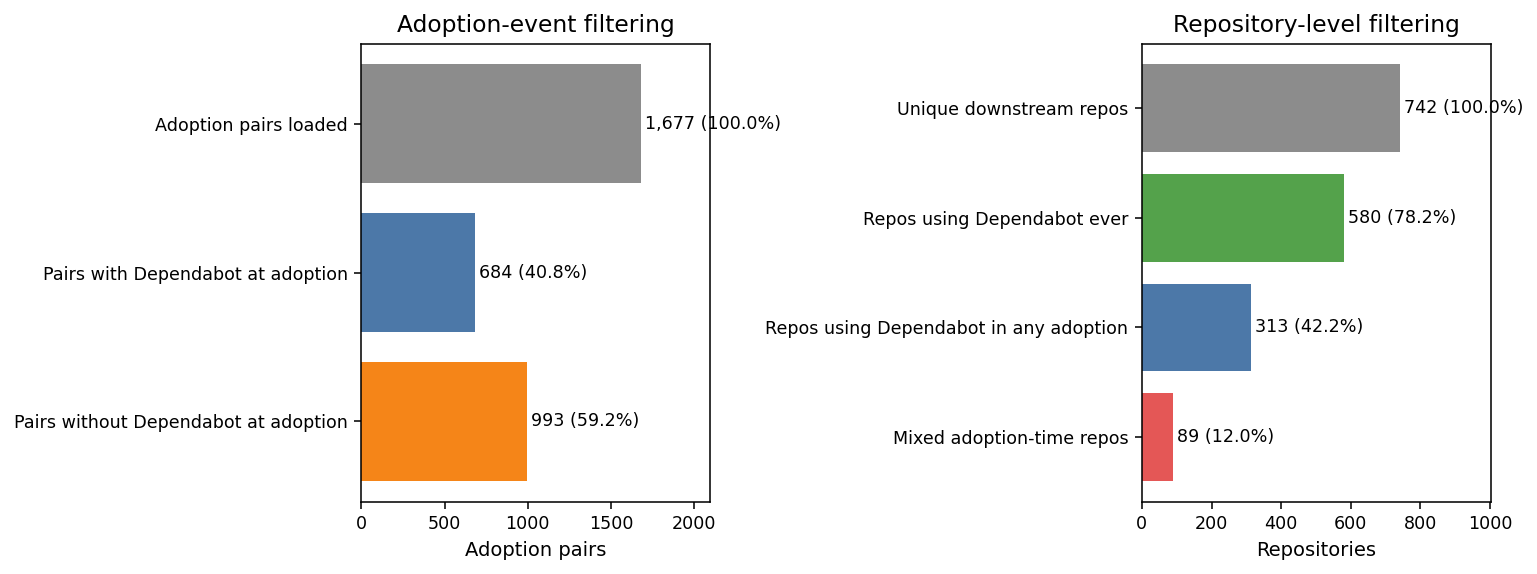

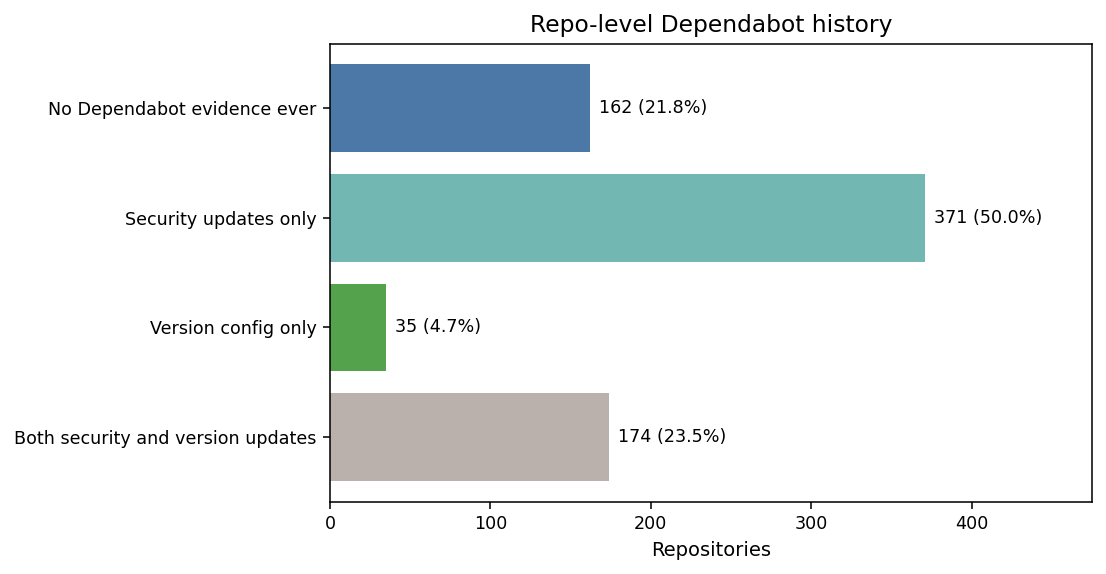

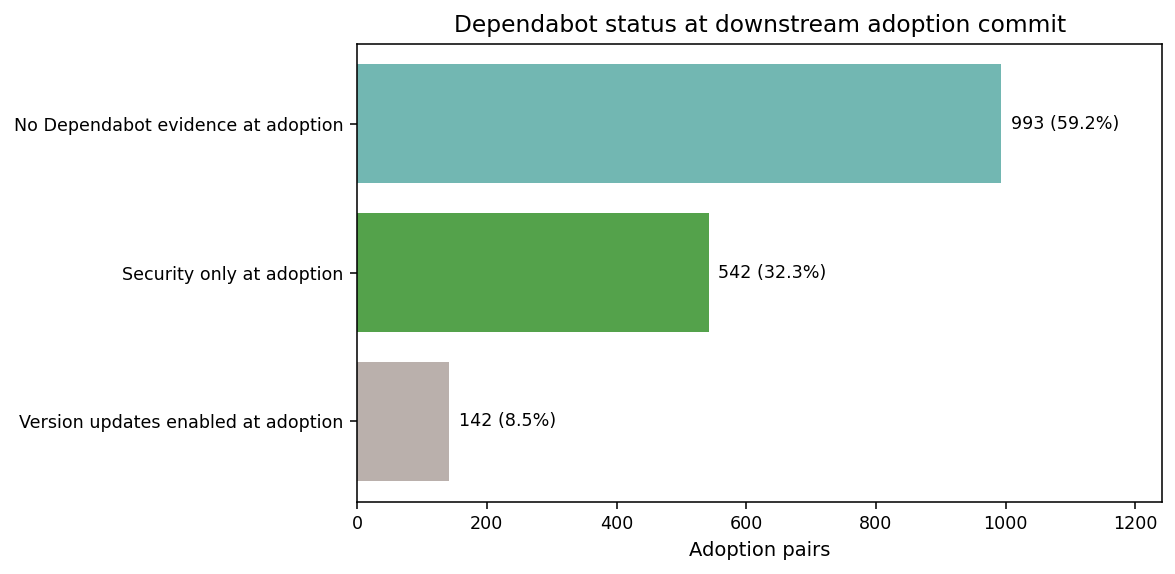

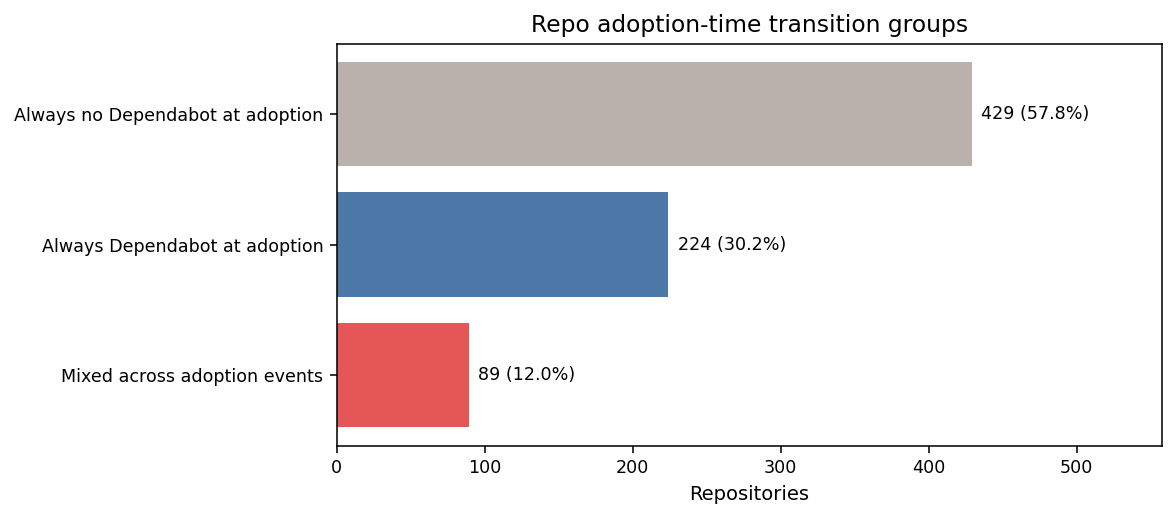

/var/folders/49/199vrwcn1zqb7rx4rgy0xhbr0000gn/T/ipykernel_90845/654105403.py:82: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=delay_plot_labels, showfliers=False, patch_artist=True)


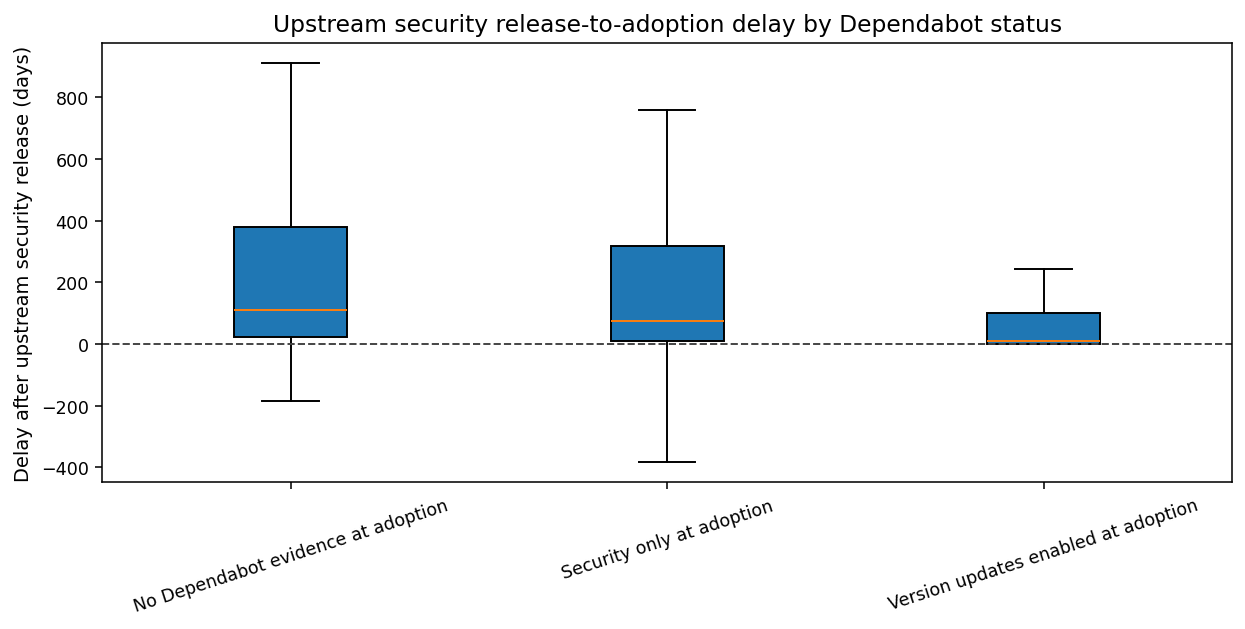

/var/folders/49/199vrwcn1zqb7rx4rgy0xhbr0000gn/T/ipykernel_90845/654105403.py:101: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(precise_box_data, labels=precise_setting_order, showfliers=False, patch_artist=True)


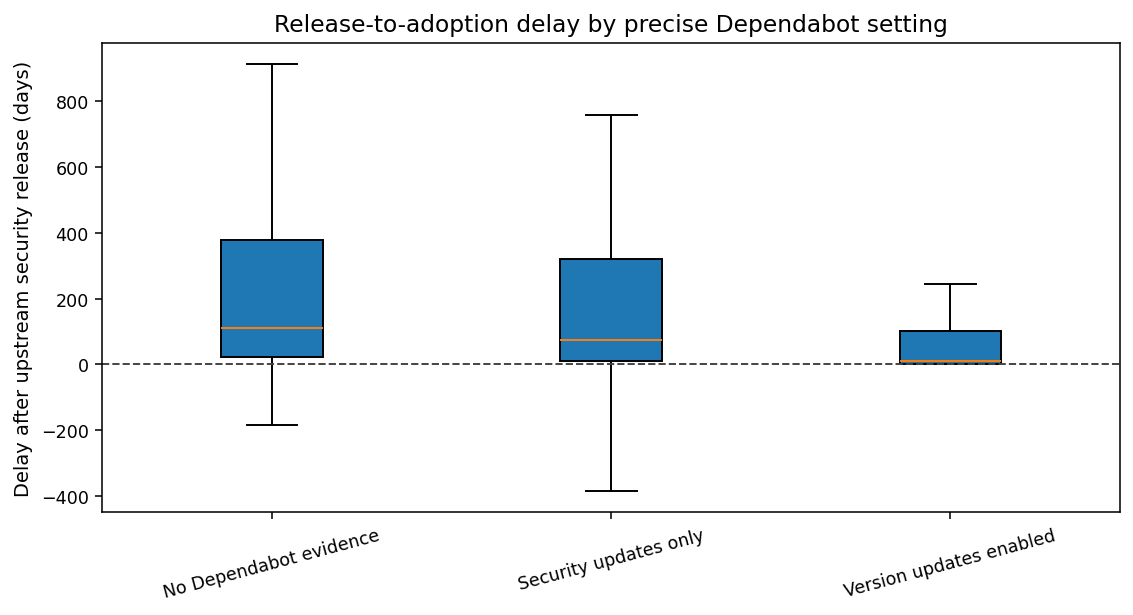

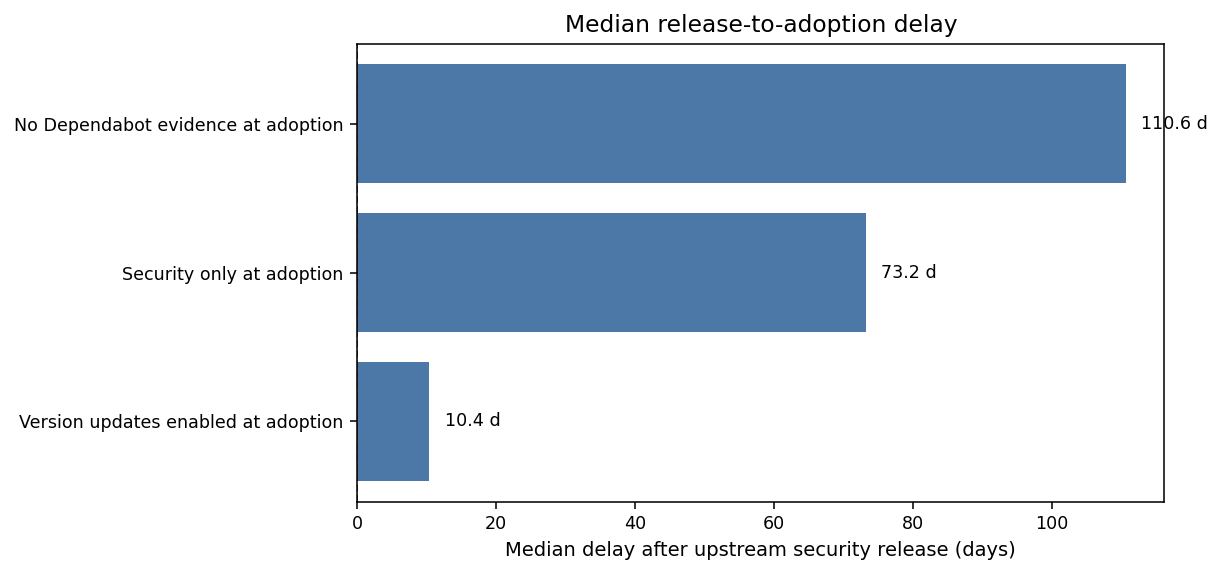

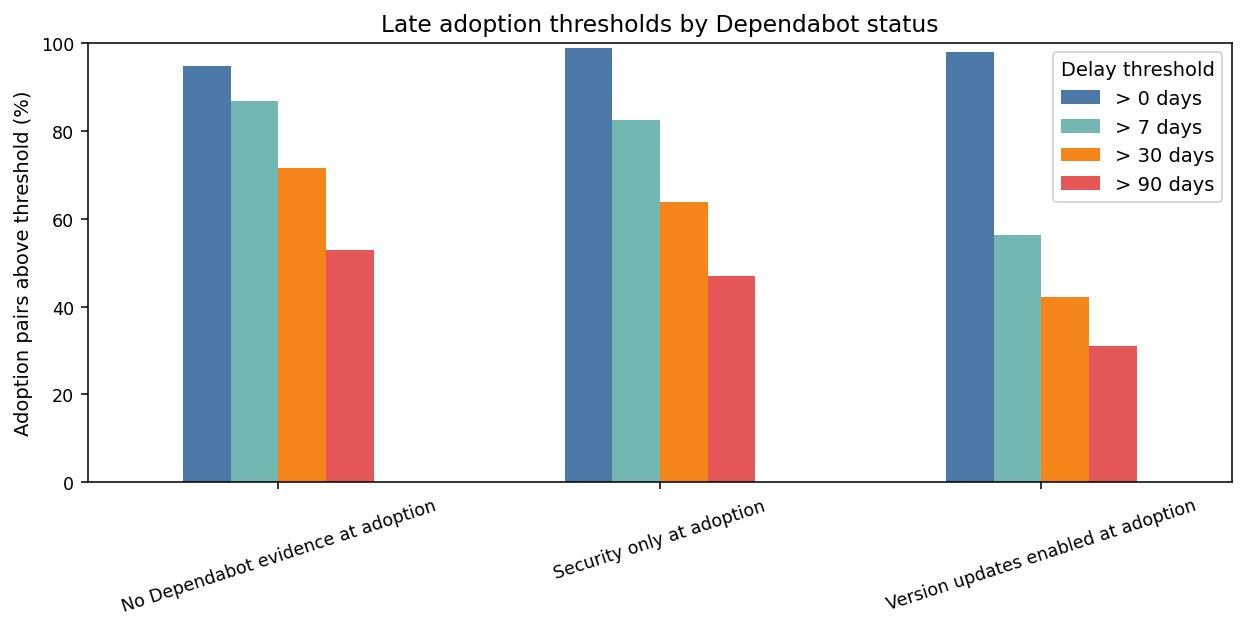

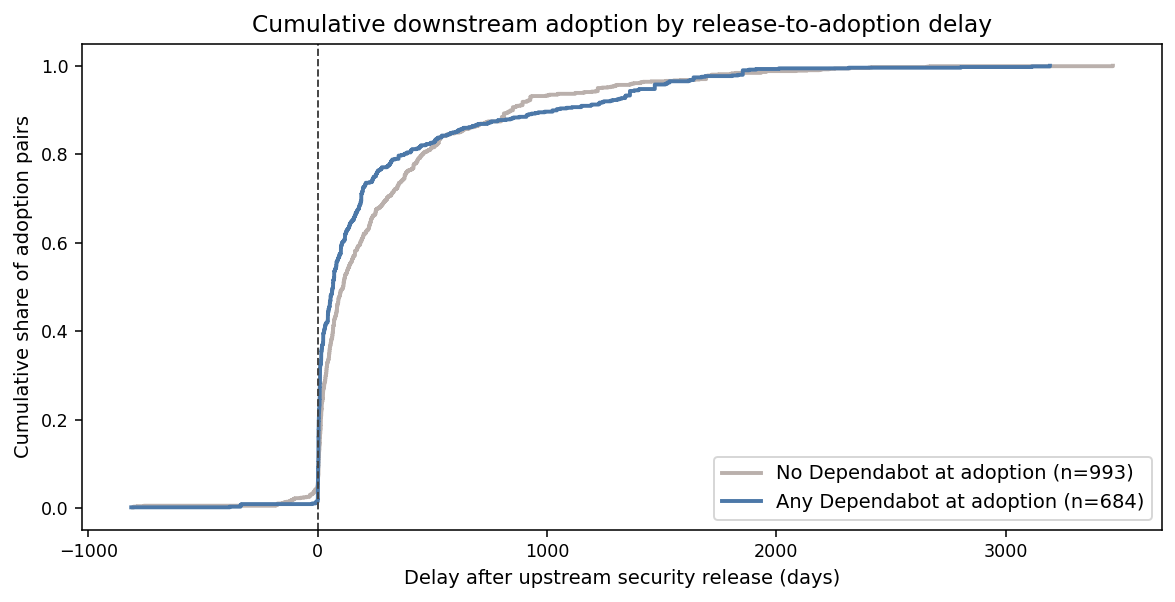

In [10]:
def add_bar_labels(ax, values, total=None, fmt='{:.1f}%'):
    for patch, value in zip(ax.patches, values):
        width = patch.get_width()
        if total:
            label = f'{int(value):,} ({value / total * 100:.1f}%)'
        else:
            label = f'{int(value):,}'
        ax.text(width + max(values) * 0.015, patch.get_y() + patch.get_height() / 2, label, va='center', ha='left', fontsize=9)

# Figure 1: systematic filtering overview, separated by unit.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
pair_values = [total_pairs, pairs_using_at_adoption, pairs_not_using_at_adoption]
pair_labels = ['Adoption pairs loaded', 'Pairs with Dependabot at adoption', 'Pairs without Dependabot at adoption']
repo_values = [unique_repos, repos_using_ever, repos_any_at_adoption, repos_mixed_at_adoption]
repo_labels = ['Unique downstream repos', 'Repos using Dependabot ever', 'Repos using Dependabot in any adoption', 'Mixed adoption-time repos']

axes[0].barh(pair_labels[::-1], pair_values[::-1], color=['#8c8c8c', '#4c78a8', '#f58518'][::-1])
axes[0].set_title('Adoption-event filtering')
axes[0].set_xlabel('Adoption pairs')
add_bar_labels(axes[0], pair_values[::-1], total_pairs)
axes[0].set_xlim(0, max(pair_values) * 1.25)

axes[1].barh(repo_labels[::-1], repo_values[::-1], color=['#8c8c8c', '#54a24b', '#4c78a8', '#e45756'][::-1])
axes[1].set_title('Repository-level filtering')
axes[1].set_xlabel('Repositories')
add_bar_labels(axes[1], repo_values[::-1], unique_repos)
axes[1].set_xlim(0, max(repo_values) * 1.35)

fig.tight_layout()
fig.savefig(FIGURE_DIR / 'rq3_systematic_filtering_overview.png', bbox_inches='tight')
plt.show()

# Figure 2: repo history usage type.
fig, ax = plt.subplots(figsize=(8, 4.2))
plot_df = repo_history_usage.iloc[::-1]
ax.barh(plot_df['label'], plot_df['repositories'], color=['#4c78a8', '#72b7b2', '#54a24b', '#bab0ac'][::-1])
ax.set_title('Repo-level Dependabot history')
ax.set_xlabel('Repositories')
add_bar_labels(ax, plot_df['repositories'].tolist(), unique_repos)
ax.set_xlim(0, plot_df['repositories'].max() * 1.28)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'rq3_repo_history_usage_type.png', bbox_inches='tight')
plt.show()

# Figure 3: adoption-time pair status.
fig, ax = plt.subplots(figsize=(8.5, 4.2))
plot_df = pair_status.iloc[::-1]
ax.barh(plot_df['label'], plot_df['adoption_pairs'], color=['#4c78a8', '#72b7b2', '#54a24b', '#bab0ac'][::-1])
ax.set_title('Dependabot status at downstream adoption commit')
ax.set_xlabel('Adoption pairs')
add_bar_labels(ax, plot_df['adoption_pairs'].tolist(), total_pairs)
ax.set_xlim(0, plot_df['adoption_pairs'].max() * 1.25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'rq3_adoption_time_pair_status.png', bbox_inches='tight')
plt.show()

# Figure 4: repo-level adoption-time transition groups.
transition_order = [
    'always_no_dependabot_at_observed_adoptions',
    'always_dependabot_at_observed_adoptions',
    'mixed_no_then_dependabot_across_observed_adoptions',
]
plot_df = repo_transition.set_index('transition_group').reindex(transition_order).reset_index()
fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.barh(plot_df['label'][::-1], plot_df['repositories'][::-1], color=['#bab0ac', '#4c78a8', '#e45756'][::-1])
ax.set_title('Repo adoption-time transition groups')
ax.set_xlabel('Repositories')
add_bar_labels(ax, plot_df['repositories'][::-1].tolist(), unique_repos)
ax.set_xlim(0, plot_df['repositories'].max() * 1.3)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'rq3_repo_adoption_time_transition.png', bbox_inches='tight')
plt.show()

# Figure 5: release-to-adoption delay by Dependabot status.
delay_plot_order = status_order
delay_plot_labels = [status_labels[status] for status in delay_plot_order]
box_data = [
    delay_data.loc[delay_data['dependabot_status_at_adoption'].eq(status), 'delay_release_days'].dropna()
    for status in delay_plot_order
]
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.boxplot(box_data, labels=delay_plot_labels, showfliers=False, patch_artist=True)
ax.axhline(0, color='#444444', linewidth=1, linestyle='--')
ax.set_title('Upstream security release-to-adoption delay by Dependabot status')
ax.set_ylabel('Delay after upstream security release (days)')
ax.tick_params(axis='x', rotation=18)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'rq3_delay_boxplot_by_dependabot_status.png', bbox_inches='tight')
plt.show()

# Figure 5b: release-to-adoption delay comparison using the verified adoption-time settings.
precise_box_data = [
    full_delay_data.loc[
        full_delay_data['adoption_time_setting_precise'].eq(setting)
        & full_delay_data['include_in_precise_setting_delay_analysis'],
        'delay_release_days'
    ].dropna()
    for setting in precise_setting_order
]
fig, ax = plt.subplots(figsize=(8.2, 4.5))
ax.boxplot(precise_box_data, labels=precise_setting_order, showfliers=False, patch_artist=True)
ax.axhline(0, color='#444444', linewidth=1, linestyle='--')
ax.set_title('Release-to-adoption delay by precise Dependabot setting')
ax.set_ylabel('Delay after upstream security release (days)')
ax.tick_params(axis='x', rotation=15)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'rq3_delay_boxplot_by_precise_setting.png', bbox_inches='tight')
plt.show()

# Figure 6: median delay by Dependabot status.
plot_df = delay_by_status.copy()
fig, ax = plt.subplots(figsize=(8.8, 4.2))
ax.barh(plot_df['label'][::-1], plot_df['median_delay_release_days'][::-1], color='#4c78a8')
ax.axvline(0, color='#444444', linewidth=1, linestyle='--')
ax.set_title('Median release-to-adoption delay')
ax.set_xlabel('Median delay after upstream security release (days)')
for patch, value in zip(ax.patches, plot_df['median_delay_release_days'][::-1]):
    x = patch.get_width()
    ax.text(x + max(plot_df['median_delay_release_days'].max() * 0.02, 1), patch.get_y() + patch.get_height() / 2, f'{value:.1f} d', va='center', ha='left', fontsize=9)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'rq3_median_delay_by_dependabot_status.png', bbox_inches='tight')
plt.show()

# Figure 7: lateness thresholds by Dependabot status.
threshold_plot = lateness_thresholds.set_index('label')[threshold_cols].rename(columns={
    'percent_after_release_gt_0d': '> 0 days',
    'percent_late_gt_7d': '> 7 days',
    'percent_late_gt_30d': '> 30 days',
    'percent_late_gt_90d': '> 90 days',
})
fig, ax = plt.subplots(figsize=(9, 4.6))
threshold_plot.plot(kind='bar', ax=ax, color=['#4c78a8', '#72b7b2', '#f58518', '#e45756'])
ax.set_title('Late adoption thresholds by Dependabot status')
ax.set_ylabel('Adoption pairs above threshold (%)')
ax.set_xlabel('')
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=18)
ax.legend(title='Delay threshold')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'rq3_lateness_thresholds_by_dependabot_status.png', bbox_inches='tight')
plt.show()

# Figure 8: ECDF for no Dependabot vs any Dependabot at adoption.
fig, ax = plt.subplots(figsize=(8.5, 4.4))
for key, label, color in [
    ('no_dependabot_at_adoption', 'No Dependabot at adoption', '#bab0ac'),
    ('any_dependabot_at_adoption', 'Any Dependabot at adoption', '#4c78a8'),
]:
    values = delay_data.loc[delay_data['any_dependabot_at_adoption'].eq(key), 'delay_release_days'].dropna().sort_values().to_numpy()
    if len(values) == 0:
        continue
    y = np.arange(1, len(values) + 1) / len(values)
    ax.step(values, y, where='post', label=f'{label} (n={len(values):,})', color=color, linewidth=2)
ax.axvline(0, color='#444444', linewidth=1, linestyle='--')
ax.set_title('Cumulative downstream adoption by release-to-adoption delay')
ax.set_xlabel('Delay after upstream security release (days)')
ax.set_ylabel('Cumulative share of adoption pairs')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'rq3_delay_ecdf_any_dependabot.png', bbox_inches='tight')
plt.show()

## Paper-Ready Compact Tables

The detailed tables above are useful for auditability. For the paper, the following three compact tables are sufficient for the main RQ3 narrative.

In [11]:
paper_T1 = pd.DataFrame([
    {'analysis_level': 'Adoption pairs', 'measure': 'RQ2 observed adoption pairs', 'count': total_pairs, 'base': total_pairs, 'percent': 100.0, 'interpretation': 'Observed CVE-UP-DOWN downstream adoption events used for RQ3.'},
    {'analysis_level': 'Repositories', 'measure': 'Unique downstream repositories', 'count': unique_repos, 'base': unique_repos, 'percent': 100.0, 'interpretation': 'Unique downstream GitHub repositories represented in the adoption pairs.'},
    {'analysis_level': 'Repository history', 'measure': 'Repositories with Dependabot evidence ever', 'count': repos_using_ever, 'base': unique_repos, 'percent': repos_using_ever / unique_repos * 100, 'interpretation': 'Broad repository-level Dependabot adoption, independent of adoption date.'},
    {'analysis_level': 'Adoption time', 'measure': 'Adoption pairs with Dependabot evidence by adoption date', 'count': pairs_using_at_adoption, 'base': total_pairs, 'percent': pairs_using_at_adoption / total_pairs * 100, 'interpretation': 'Adoption events where Dependabot evidence existed on or before the downstream adoption commit.'},
    {'analysis_level': 'Adoption time repositories', 'measure': 'Repositories with Dependabot in at least one observed adoption event', 'count': repos_any_at_adoption, 'base': unique_repos, 'percent': repos_any_at_adoption / unique_repos * 100, 'interpretation': 'Repositories where Dependabot was active for at least one observed adoption event.'},
    {'analysis_level': 'Adoption time repositories', 'measure': 'Repositories with mixed adoption-time status', 'count': repos_mixed_at_adoption, 'base': unique_repos, 'percent': repos_mixed_at_adoption / unique_repos * 100, 'interpretation': 'Repositories that lacked Dependabot for some adoption events but had it for later adoption events.'},
])
paper_T1.to_csv(TABLE_DIR / 'rq3_paper_T1_dependabot_coverage.csv', index=False)

paper_T2 = delay_by_precise_setting[[
    'adoption_time_setting_precise', 'label', 'adoption_pairs', 'downstream_repositories', 'cves',
    'median_delay_release_days', 'q1_delay_release_days', 'q3_delay_release_days',
    'percent_late_gt_30d', 'percent_late_gt_90d',
]].copy()
paper_T2['percent_of_adoption_pairs'] = paper_T2['adoption_pairs'] / total_pairs * 100
paper_T2['iqr_delay_release_days'] = paper_T2.apply(lambda row: f'{row.q1_delay_release_days:.1f}-{row.q3_delay_release_days:.1f}', axis=1)
paper_T2 = paper_T2[[
    'adoption_time_setting_precise', 'label', 'adoption_pairs', 'percent_of_adoption_pairs',
    'downstream_repositories', 'cves', 'median_delay_release_days', 'iqr_delay_release_days',
    'percent_late_gt_30d', 'percent_late_gt_90d',
]]
paper_T2.to_csv(TABLE_DIR / 'rq3_paper_T2_adoption_time_status_and_delay.csv', index=False)

paper_T3 = security_then_version_strategy.copy()
paper_T3.to_csv(TABLE_DIR / 'rq3_paper_T3_security_then_version_strategy.csv', index=False)

display(paper_T1)
display(paper_T2)
display(paper_T3)

,analysis_level,measure,count,base,percent,interpretation
0,Adoption pairs,RQ2 observed adoption pairs,1677,1677,100.000000,Observed CVE-UP-DOWN downstream adoption event...
1,Repositories,Unique downstream repositories,742,742,100.000000,Unique downstream GitHub repositories represen...
2,Repository history,Repositories with Dependabot evidence ever,580,742,78.167116,"Broad repository-level Dependabot adoption, in..."
3,Adoption time,Adoption pairs with Dependabot evidence by ado...,684,1677,40.787120,Adoption events where Dependabot evidence exis...
4,Adoption time repositories,Repositories with Dependabot in at least one o...,313,742,42.183288,Repositories where Dependabot was active for a...
5,Adoption time repositories,Repositories with mixed adoption-time status,89,742,11.994609,Repositories that lacked Dependabot for some a...


,adoption_time_setting_precise,label,adoption_pairs,percent_of_adoption_pairs,downstream_repositories,cves,median_delay_release_days,iqr_delay_release_days,percent_late_gt_30d,percent_late_gt_90d
0,No Dependabot evidence,No Dependabot evidence,993,59.212880,518,168,110.641308,22.5-378.9,71.601208,52.870091
1,Security updates only,Security updates only,542,32.319618,251,133,73.165075,10.0-318.6,63.837638,46.863469
2,Version updates enabled,Version updates enabled,142,8.467501,74,44,10.365098,1.3-101.0,42.253521,30.985915


,measure,count,base,percent,median_transition_days,iqr_transition_days,interpretation
0,Repositories with security-first then version-...,147,742,19.811321,585.000301,351.9-936.8,First Dependabot PR evidence precedes dependab...
1,Adoption pairs security-only at adoption but v...,137,1677,8.169350,NaN,NaN,"At the adoption commit, only security-update e..."


## Final Takeaways

In [12]:
no_dep_median = delay_any.loc[delay_any['any_dependabot_at_adoption'].eq('no_dependabot_at_adoption'), 'median_delay_release_days'].iloc[0]
any_dep_median = delay_any.loc[delay_any['any_dependabot_at_adoption'].eq('any_dependabot_at_adoption'), 'median_delay_release_days'].iloc[0]
any_dep_late_30 = delay_any.loc[delay_any['any_dependabot_at_adoption'].eq('any_dependabot_at_adoption'), 'percent_late_gt_30d'].iloc[0]
any_dep_late_90 = delay_any.loc[delay_any['any_dependabot_at_adoption'].eq('any_dependabot_at_adoption'), 'percent_late_gt_90d'].iloc[0]
security_only_median = delay_by_precise_setting.loc[delay_by_precise_setting['adoption_time_setting_precise'].eq('Security updates only'), 'median_delay_release_days'].iloc[0]
version_enabled_median = delay_by_precise_setting.loc[delay_by_precise_setting['adoption_time_setting_precise'].eq('Version updates enabled'), 'median_delay_release_days'].iloc[0]
security_then_version_repo_count = int(security_then_version_strategy.loc[security_then_version_strategy['measure'].str.startswith('Repositories'), 'count'].iloc[0])

takeaways = [
    f'The RQ2 input contains {total_pairs:,} adoption pairs from {unique_repos:,} unique downstream repositories.',
    f'Across full repository history, {repos_using_ever:,}/{unique_repos:,} repositories ({repos_using_ever / unique_repos * 100:.1f}%) show Dependabot evidence.',
    f'At adoption time, {pairs_using_at_adoption:,}/{total_pairs:,} adoption events ({pairs_using_at_adoption / total_pairs * 100:.1f}%) had Dependabot evidence on or before the adoption commit date.',
    f'At the repository level, {repos_any_at_adoption:,}/{unique_repos:,} repositories ({repos_any_at_adoption / unique_repos * 100:.1f}%) used Dependabot in at least one observed adoption event.',
    f'{repos_mixed_at_adoption:,} repositories had mixed adoption-time status, meaning they were not using Dependabot for some observed adoptions but were using it for later observed adoptions.',
    f'Median release-to-adoption delay was {no_dep_median:.1f} days without Dependabot at adoption and {any_dep_median:.1f} days with any Dependabot evidence at adoption.',
    f'In the adoption-time setting comparison, security-updates-only adoption events had median delay {security_only_median:.1f} days, while version-updates-enabled events had median delay {version_enabled_median:.1f} days.',
    f'Among adoption events with Dependabot evidence at adoption, {any_dep_late_30:.1f}% were still more than 30 days late and {any_dep_late_90:.1f}% were still more than 90 days late.',
    f'{security_then_version_repo_count:,} repositories show a security-first then version-update lifecycle, indicating a downstream strategy transition from Dependabot security-update evidence to explicit version-update configuration.',
]

for item in takeaways:
    print('- ' + item)

- The RQ2 input contains 1,677 adoption pairs from 742 unique downstream repositories.
- Across full repository history, 580/742 repositories (78.2%) show Dependabot evidence.
- At adoption time, 684/1,677 adoption events (40.8%) had Dependabot evidence on or before the adoption commit date.
- At the repository level, 313/742 repositories (42.2%) used Dependabot in at least one observed adoption event.
- 89 repositories had mixed adoption-time status, meaning they were not using Dependabot for some observed adoptions but were using it for later observed adoptions.
- Median release-to-adoption delay was 110.6 days without Dependabot at adoption and 66.8 days with any Dependabot evidence at adoption.
- In the adoption-time setting comparison, security-updates-only adoption events had median delay 73.2 days, while version-updates-enabled events had median delay 10.4 days.
- Among adoption events with Dependabot evidence at adoption, 59.4% were still more than 30 days late and 43.6% were s

## Final Compact Delay Table

This final table is formatted for direct use in the RQ3 findings. Percentages in adoption pairs use the full 1,677-pair denominator; lateness percentages use the row denominator.

In [13]:
compact_order = ['No Dependabot evidence', 'Security updates only', 'Version updates enabled']
compact_rows = []
for state in compact_order:
    subset = pairwise[pairwise['adoption_time_setting_precise'].eq(state)].copy()
    n = len(subset)
    late_30 = int(subset['delay_release_days'].gt(30).sum())
    late_90 = int(subset['delay_release_days'].gt(90).sum())
    median_delay = subset['delay_release_days'].median()
    compact_rows.append({
        'Dependabot state': state,
        'Adoption pairs': f'{n:,} ({n / total_pairs * 100:.1f}%)',
        'Median delay': f'{median_delay:.1f} days',
        '>30 days late': f'{late_30:,} ({late_30 / n * 100:.1f}%)',
        '>90 days late': f'{late_90:,} ({late_90 / n * 100:.1f}%)',
    })

subset = pairwise.copy()
n = len(subset)
late_30 = int(subset['delay_release_days'].gt(30).sum())
late_90 = int(subset['delay_release_days'].gt(90).sum())
median_delay = subset['delay_release_days'].median()
compact_rows.append({
    'Dependabot state': 'Total',
    'Adoption pairs': f'{n:,} (100.0%)',
    'Median delay': f'{median_delay:.1f} days',
    '>30 days late': f'{late_30:,} ({late_30 / n * 100:.1f}%)',
    '>90 days late': f'{late_90:,} ({late_90 / n * 100:.1f}%)',
})

compact_delay_table = pd.DataFrame(compact_rows)
compact_delay_table.to_csv(TABLE_DIR / 'rq3_final_compact_delay_table.csv', index=False)
display(compact_delay_table)


,Dependabot state,Adoption pairs,Median delay,>30 days late,>90 days late
0,No Dependabot evidence,993 (59.2%),110.6 days,711 (71.6%),525 (52.9%)
1,Security updates only,542 (32.3%),73.2 days,346 (63.8%),254 (46.9%)
2,Version updates enabled,142 (8.5%),10.4 days,60 (42.3%),44 (31.0%)
3,Total,"1,677 (100.0%)",85.6 days,"1,117 (66.6%)",823 (49.1%)
